<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/soil_quality-analysis_and_predictive_modeling/Soil_Quality_Analysis_and_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Final comparison (Soil pH Prediction Test Set)
           Model      MAE     RMSE  R2 Score
   Random Forest 0.502841 0.651209  0.256994
             SVR 0.523976 0.726650  0.074873
         XGBoost 0.562292 0.672711  0.207118
Ridge Regression 0.569561 0.757953 -0.006550



/tmp/ipykernel_895/437505870.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')


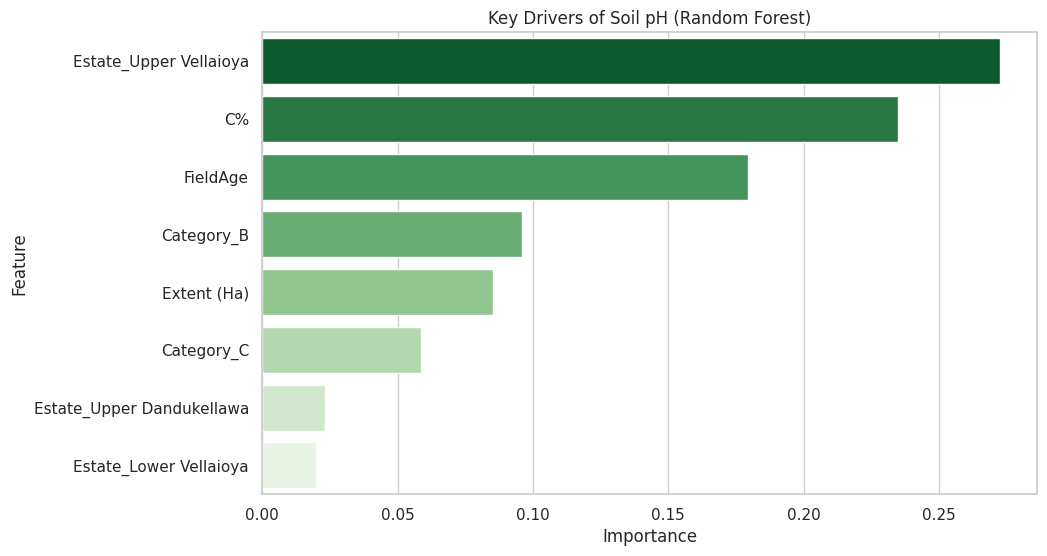

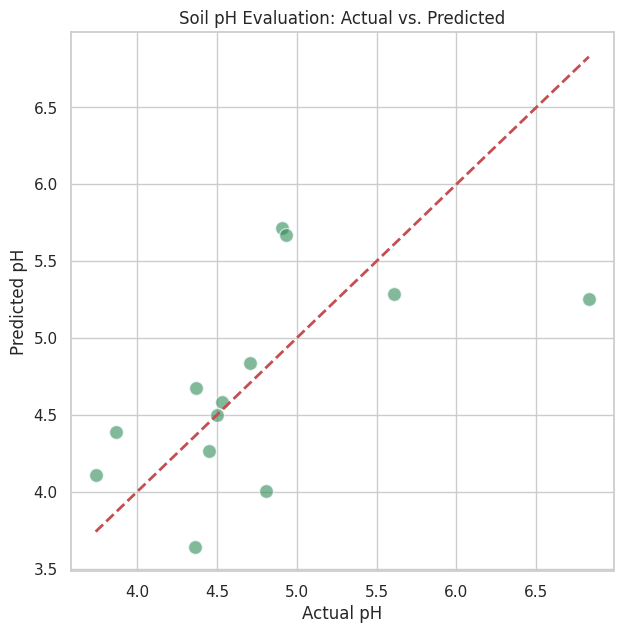

/tmp/ipykernel_895/437505870.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=comparison_df, palette='viridis')


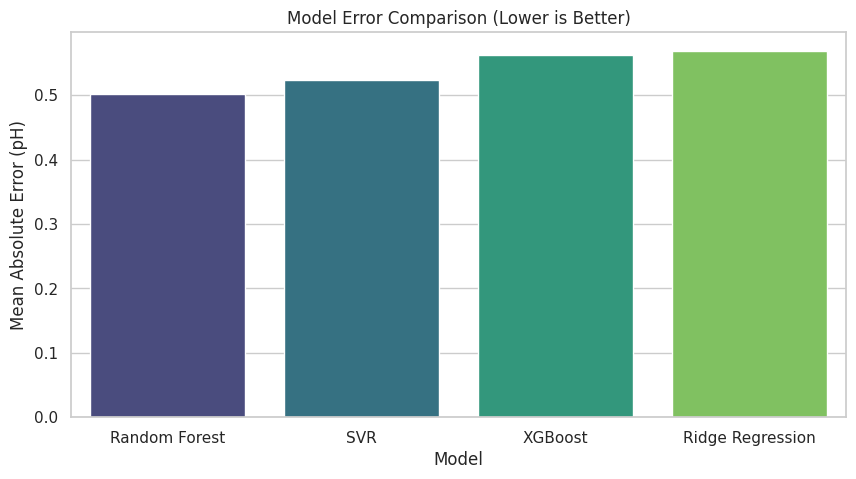

In [6]:
# ==========================================================
# STEMS - Smart Tea Estate Management System
# Improved Models, Visualizations & Model Comparison
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Imports
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
import xgboost as xgb

# Set aesthetic style
sns.set_theme(style="whitegrid")

# ==========================================================
# 1. Load and Clean Soil Data
# ==========================================================
soil = pd.read_csv("sample_data/soil_data.csv")
soil.replace("missing", np.nan, inplace=True)
soil["pH"] = pd.to_numeric(soil["pH"], errors="coerce")
soil["C%"] = pd.to_numeric(soil["C%"], errors="coerce")
soil["Year of Planting"] = pd.to_numeric(soil["Year of Planting"], errors="coerce")
soil = soil.dropna()
soil["FieldAge"] = 2025 - soil["Year of Planting"]

features = ["Extent (Ha)", "Category", "VP/SD", "Estate", "FieldAge", "C%"]
X = soil[features]
y = soil["pH"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================================
# 2. Model Comparison Logic (For the Table)
# ==========================================================
categorical_cols = ["Category", "VP/SD", "Estate"]
numeric_cols = ["Extent (Ha)", "FieldAge", "C%"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols) # Added scaling for SVR/Ridge
])

models = {
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2})

# Display the Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by="MAE")
print("\n" + "="*60)
print("Final comparison (Soil pH Prediction Test Set)")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60 + "\n")

# ==========================================================
# 3. Final Visualizations (The 3 Required Images)
# ==========================================================

# IMAGE 1: Soil Quality - Feature Importance (Using RF)
best_rf = Pipeline([("prep", preprocessor), ("model", models["Random Forest"])])
best_rf.fit(X_train, y_train)

plt.figure(figsize=(10, 6))
ohe_names = list(best_rf.named_steps['prep'].transformers_[0][1].get_feature_names_out())
all_feat_names = ohe_names + numeric_cols
importances = best_rf.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_feat_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(8)

sns.barplot(x='Importance', y='Feature', data=feat_df, palette='Greens_r')
plt.title("Key Drivers of Soil pH (Random Forest)")
plt.show()

# IMAGE 2: Actual vs Predicted Scatter (Model Evaluation)
# Based on your documentation, RF is the best for Soil
rf_preds = best_rf.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_preds, alpha=0.6, color='seagreen', edgecolors='w', s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Soil pH Evaluation: Actual vs. Predicted")
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.show()

# IMAGE 3: Performance Metrics Comparison (Bar Chart)
# This visualizes the table results for the report
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MAE', data=comparison_df, palette='viridis')
plt.title("Model Error Comparison (Lower is Better)")
plt.ylabel("Mean Absolute Error (pH)")
plt.show()

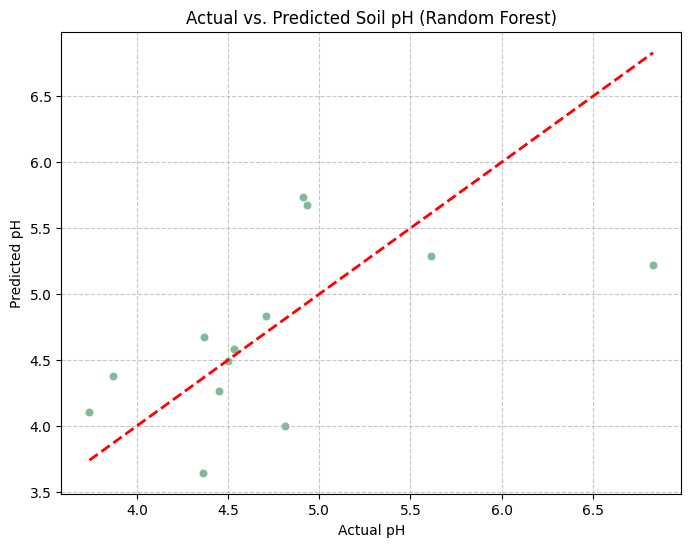

/tmp/ipykernel_895/2618002181.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


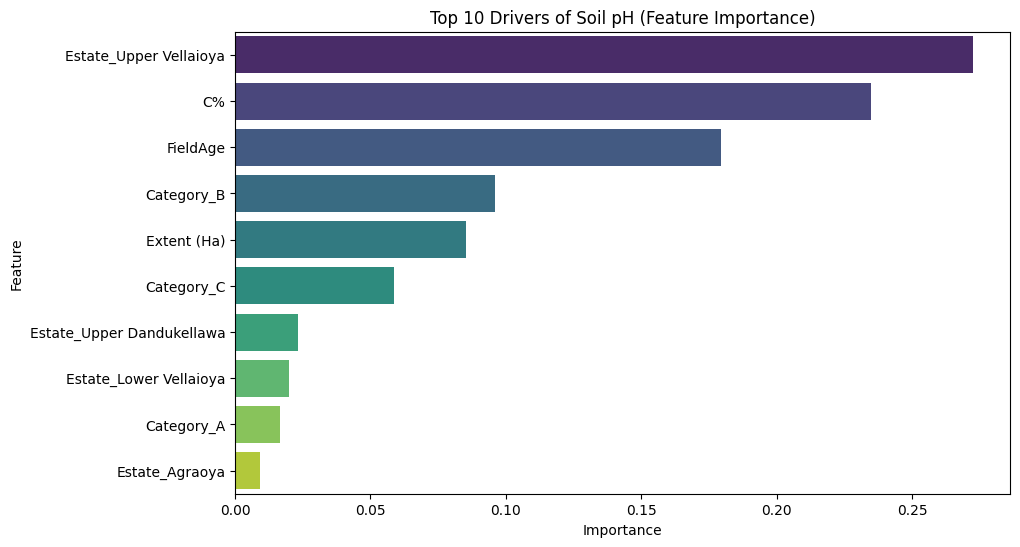

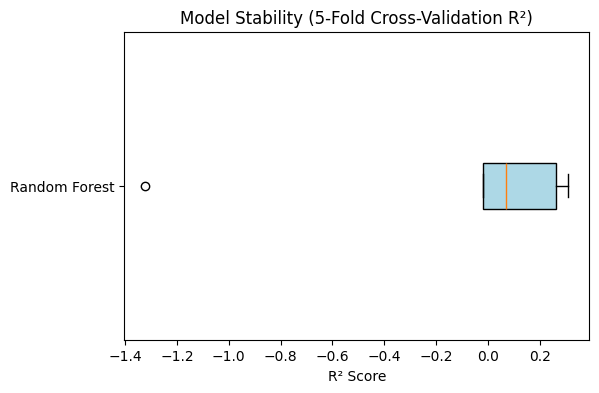

In [4]:
# ==========================================================
# 9. Enhanced Soil Quality Visualizations
# ==========================================================
import seaborn as sns

# 1. Actual vs Predicted Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=soil_pred, alpha=0.6, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title("Actual vs. Predicted Soil pH (Random Forest)")
plt.xlabel("Actual pH")
plt.ylabel("Predicted pH")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Feature Importance Plot
# Get feature names after one-hot encoding
ohe_features = list(pipeline.named_steps['preprocess'].transformers_[0][1].get_feature_names_out())
all_features = ohe_features + numeric_cols

importances = pipeline.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title("Top 10 Drivers of Soil pH (Feature Importance)")
plt.show()

# 3. Cross-Validation Results
plt.figure(figsize=(6, 4))
plt.boxplot(scores, vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Model Stability (5-Fold Cross-Validation R²)")
plt.xlabel("R² Score")
plt.yticks([1], ["Random Forest"])
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')